# AG News Text Classification
### Comparing Logistic Regression, Random Forest, BiLSTM, and Transformer
**CSE 4705**

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, time, warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import trange, tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Dataset & EDA

In [2]:
dataset    = load_dataset("fancyzhx/ag_news")
LABELS     = dataset["train"].features["label"].names  # World, Sports, Business, Sci/Tech
NUM_CLASSES = len(LABELS)

train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])
train_df["label_name"] = train_df["label"].map(lambda x: LABELS[x])
test_df["label_name"]  = test_df["label"].map(lambda x: LABELS[x])

print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}  |  Classes: {LABELS}")
train_df.head(3)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 120,000  |  Test: 7,600  |  Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business


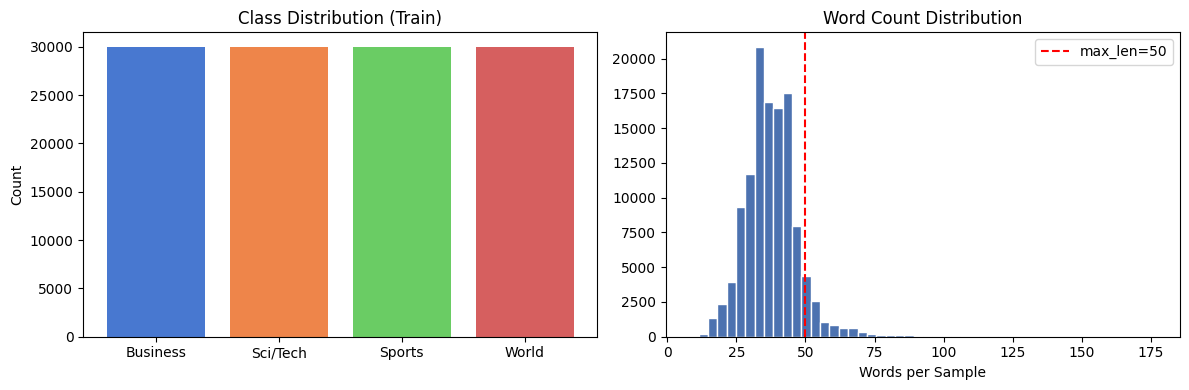

Avg words: 37.8  |  % under 50 words: 93.1%


In [3]:
# Class distribution + text length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train_df["label_name"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=sns.color_palette("muted", 4))
axes[0].set_title("Class Distribution (Train)")
axes[0].set_ylabel("Count")

train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))
axes[1].hist(train_df["word_count"], bins=50, color="#4C72B0", edgecolor="white")
axes[1].axvline(50, color="red", linestyle="--", label="max_len=50")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words per Sample")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda.png", bbox_inches="tight")
plt.show()

print(f"Avg words: {train_df['word_count'].mean():.1f}  |  "
      f"% under 50 words: {(train_df['word_count']<=50).mean()*100:.1f}%")

## 2. Preprocessing

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

train_df["clean"] = train_df["text"].apply(clean_text)
test_df["clean"]  = test_df["text"].apply(clean_text)

X_train = train_df["clean"].tolist()
X_test  = test_df["clean"].tolist()
y_train = train_df["label"].tolist()
y_test  = test_df["label"].tolist()

print("Sample cleaned:", X_train[0][:120])

Sample cleaned: wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics are se


In [5]:
# TF-IDF for classical models
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2),
                        sublinear_tf=True, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (120000, 30000)


In [6]:
# Integer sequences for deep learning models
VOCAB_SIZE = 10000
MAX_LEN    = 50

word_freq = Counter(" ".join(X_train).split())
word2idx  = {w: i+2 for i, (w, _) in enumerate(word_freq.most_common(VOCAB_SIZE-2))}
word2idx["<PAD>"] = 0
word2idx["<OOV>"] = 1

def encode(texts):
    result = []
    for t in texts:
        ids = [word2idx.get(w, 1) for w in t.split()[:MAX_LEN]]
        ids += [0] * (MAX_LEN - len(ids))
        result.append(ids)
    return np.array(result, dtype=np.int32)

X_train_seq = encode(X_train)
X_test_seq  = encode(X_test)
y_train_np  = np.array(y_train)
y_test_np   = np.array(y_test)
print("Sequence shape:", X_train_seq.shape)

Sequence shape: (120000, 50)


## 3. Classical Baselines

In [7]:
results = {}

def evaluate(name, y_true, y_pred, train_time):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    results[name] = {"accuracy": acc, "f1": f1,
                     "train_time": train_time, "y_pred": y_pred,
                     "cm": confusion_matrix(y_true, y_pred)}
    print(f"\n{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Train Time: {train_time:.1f}s")
    print(classification_report(y_true, y_pred, target_names=LABELS))

In [8]:
# Logistic Regression
t0 = time.time()
lr = LogisticRegression(solver="saga", C=1.0, max_iter=1000,
                        multi_class="multinomial", random_state=SEED, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
evaluate("Logistic Regression", y_test, lr.predict(X_test_tfidf), time.time()-t0)


Logistic Regression
  Accuracy : 0.9209
  F1 Score : 0.9207
  Train Time: 3.3s
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.90      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



In [9]:
# Random Forest (smaller TF-IDF for speed)
tfidf_rf = TfidfVectorizer(max_features=10000, sublinear_tf=True,
                           stop_words="english")
Xtr_rf = tfidf_rf.fit_transform(X_train)
Xte_rf = tfidf_rf.transform(X_test)

t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(Xtr_rf, y_train)
evaluate("Random Forest", y_test, rf.predict(Xte_rf), time.time()-t0)


Random Forest
  Accuracy : 0.8937
  F1 Score : 0.8932
  Train Time: 528.7s
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      1900
      Sports       0.92      0.97      0.94      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.87      0.86      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



## 4. BiLSTM (PyTorch)

In [10]:
# Shared Dataset & DataLoader
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(X_tr, y_tr, X_te, y_te, batch=256, val=0.1):
    full = TextDataset(X_tr, y_tr)
    v = int(len(full)*val); t = len(full)-v
    tr_ds, val_ds = random_split(full, [t,v],
                    generator=torch.Generator().manual_seed(SEED))
    test_ds = TextDataset(X_te, y_te)
    return (DataLoader(tr_ds,  batch, shuffle=True),
            DataLoader(val_ds, batch),
            DataLoader(test_ds,batch))

train_loader, val_loader, test_loader = make_loaders(
    X_train_seq, y_train_np, X_test_seq, y_test_np)

In [11]:
# Shared training loop (reused for Transformer in Part 5)
def train_model(model, tr_loader, val_loader, epochs=15, lr=1e-3):
    opt      = torch.optim.Adam(model.parameters(), lr=lr)
    crit     = nn.CrossEntropyLoss()
    sched    = ReduceLROnPlateau(opt, patience=2, factor=0.5)
    history  = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_wts, best_loss, patience_cnt = None, float("inf"), 0

    for epoch in trange(1, epochs+1, desc="Epochs"):
        # --- train ---
        model.train(); tl, tc, tn = 0,0,0
        for xb, yb in tqdm(tr_loader, leave=False, desc="  train"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()*len(yb); tc += (model(xb).argmax(1)==yb).sum().item(); tn += len(yb)

        # --- val ---
        model.eval(); vl, vc, vn = 0,0,0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                vl += crit(out, yb).item()*len(yb)
                vc += (out.argmax(1)==yb).sum().item(); vn += len(yb)

        ta, va = tc/tn, vc/vn
        tl, vl = tl/tn, vl/vn
        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        sched.step(vl)

        if vl < best_loss:
            best_loss = vl
            best_wts  = {k:v.clone() for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 3:
                print(f"Early stop at epoch {epoch}")
                break

    model.load_state_dict(best_wts)
    return history

def get_preds(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)

In [12]:
# BiLSTM model
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, n_classes, n_layers=2, dropout=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden*2, n_classes)

    def forward(self, x):
        emb = self.drop(self.emb(x))
        _, (h, _) = self.lstm(emb)
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.drop(h))

lstm_model = BiLSTM(VOCAB_SIZE, 128, 128, NUM_CLASSES).to(DEVICE)
print(f"BiLSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}")

BiLSTM params: 1,940,484


In [ ]:
t0 = time.time()
lstm_hist = train_model(lstm_model, train_loader, val_loader)
lstm_time = time.time() - t0

lstm_preds, lstm_true = get_preds(lstm_model, test_loader)
evaluate("BiLSTM", lstm_true, lstm_preds, lstm_time)

Epochs:  67%|██████▋   | 10/15 [03:13<01:36, 19.32s/it]

Early stop at epoch 11



BiLSTM
  Accuracy : 0.9153
  F1 Score : 0.9151
  Train Time: 198.1s
              precision    recall  f1-score   support

       World       0.92      0.92      0.92      1900
      Sports       0.96      0.97      0.96      1900
    Business       0.89      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



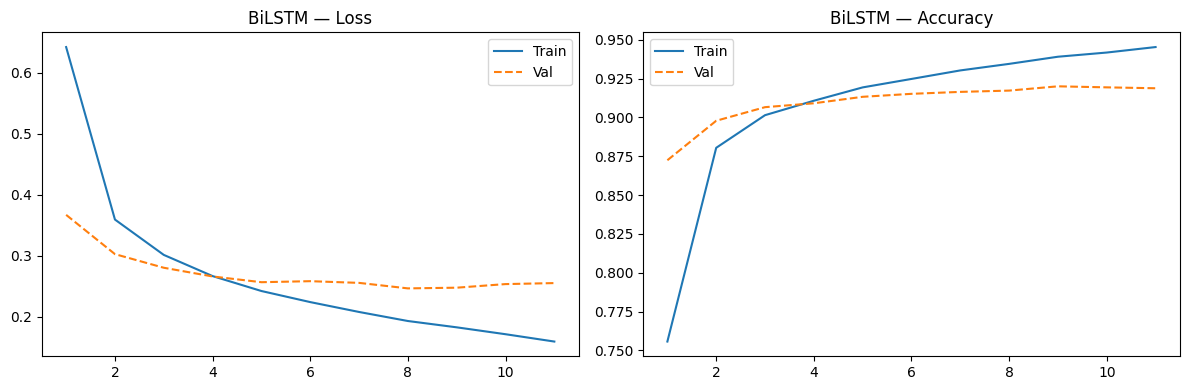

In [ ]:
# Training curves
def plot_curves(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"])+1)
    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val", linestyle="--")
    axes[0].set_title(f"{name} — Loss"); axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val", linestyle="--")
    axes[1].set_title(f"{name} — Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.savefig(f"{name.lower().replace(' ','_')}_curves.png", bbox_inches="tight")
    plt.show()

plot_curves(lstm_hist, "BiLSTM")

## 5. Transformer (PyTorch)

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers,
                 n_classes, max_len, dropout=0.1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        # Learnable positional embedding (simpler than sinusoidal)
        self.pos = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(d_model, n_classes)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        out = self.drop(self.emb(x) + self.pos(positions))
        pad_mask = (x == 0)  # ignore PAD tokens in attention
        out = self.transformer(out, src_key_padding_mask=pad_mask)
        out = out.mean(dim=1)  # global average pooling
        return self.fc(self.drop(out))

transformer_model = TransformerClassifier(
    vocab_size=VOCAB_SIZE, d_model=128, nhead=4,
    num_layers=3, n_classes=NUM_CLASSES, max_len=MAX_LEN
).to(DEVICE)
print(f"Transformer params: {sum(p.numel() for p in transformer_model.parameters()):,}")

Transformer params: 1,881,732


Epochs: 100%|██████████| 15/15 [05:02<00:00, 20.16s/it]



Transformer
  Accuracy : 0.9082
  F1 Score : 0.9080
  Train Time: 302.4s
              precision    recall  f1-score   support

       World       0.93      0.90      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.88      0.89      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



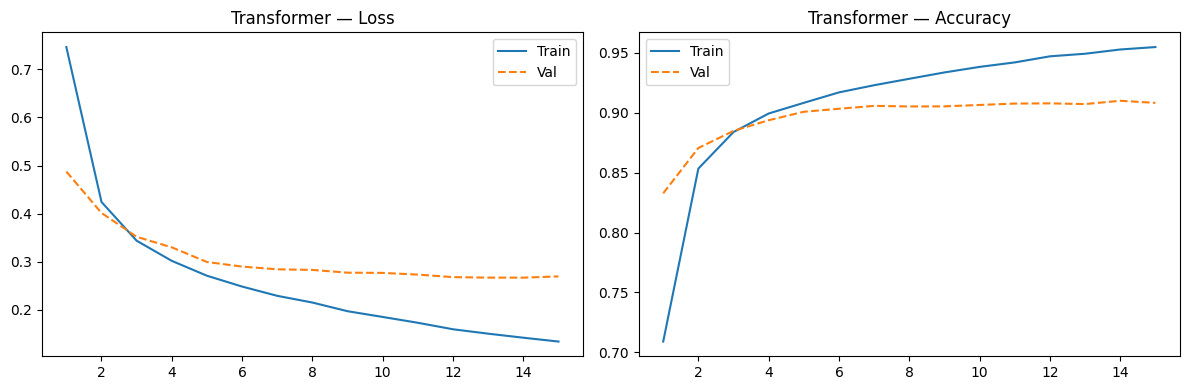

In [ ]:
t0 = time.time()
transformer_hist = train_model(transformer_model, train_loader, val_loader, lr=5e-4)
transformer_time = time.time() - t0

transformer_preds, transformer_true = get_preds(transformer_model, test_loader)
evaluate("Transformer", transformer_true, transformer_preds, transformer_time)

plot_curves(transformer_hist, "Transformer")

## 6. Results & Comparison

In [ ]:
# Summary table
rows = []
for name in ["Logistic Regression", "Random Forest", "BiLSTM", "Transformer"]:
    m = results[name]
    per_class = f1_score(y_test_np, m["y_pred"], average=None)
    rows.append({
        "Model"      : name,
        "Accuracy"   : f"{m['accuracy']*100:.2f}%",
        "F1 (wtd)"   : f"{m['f1']:.4f}",
        "Train Time" : f"{m['train_time']:.1f}s",
        "F1-World"   : f"{per_class[0]:.4f}",
        "F1-Sports"  : f"{per_class[1]:.4f}",
        "F1-Business": f"{per_class[2]:.4f}",
        "F1-Sci/Tech": f"{per_class[3]:.4f}",
    })

summary = pd.DataFrame(rows).set_index("Model")
print(summary.to_string())
summary.to_csv("results_summary.csv")

                    Accuracy F1 (wtd) Train Time F1-World F1-Sports F1-Business F1-Sci/Tech
Model                                                                                      
Logistic Regression   92.09%   0.9207       3.3s   0.9216    0.9688      0.8911      0.9015
Random Forest         89.37%   0.8932     528.7s   0.9055    0.9417      0.8581      0.8676
BiLSTM                91.53%   0.9151     198.1s   0.9203    0.9644      0.8838      0.8921
Transformer           90.82%   0.9080     302.4s   0.9113    0.9642      0.8733      0.8832


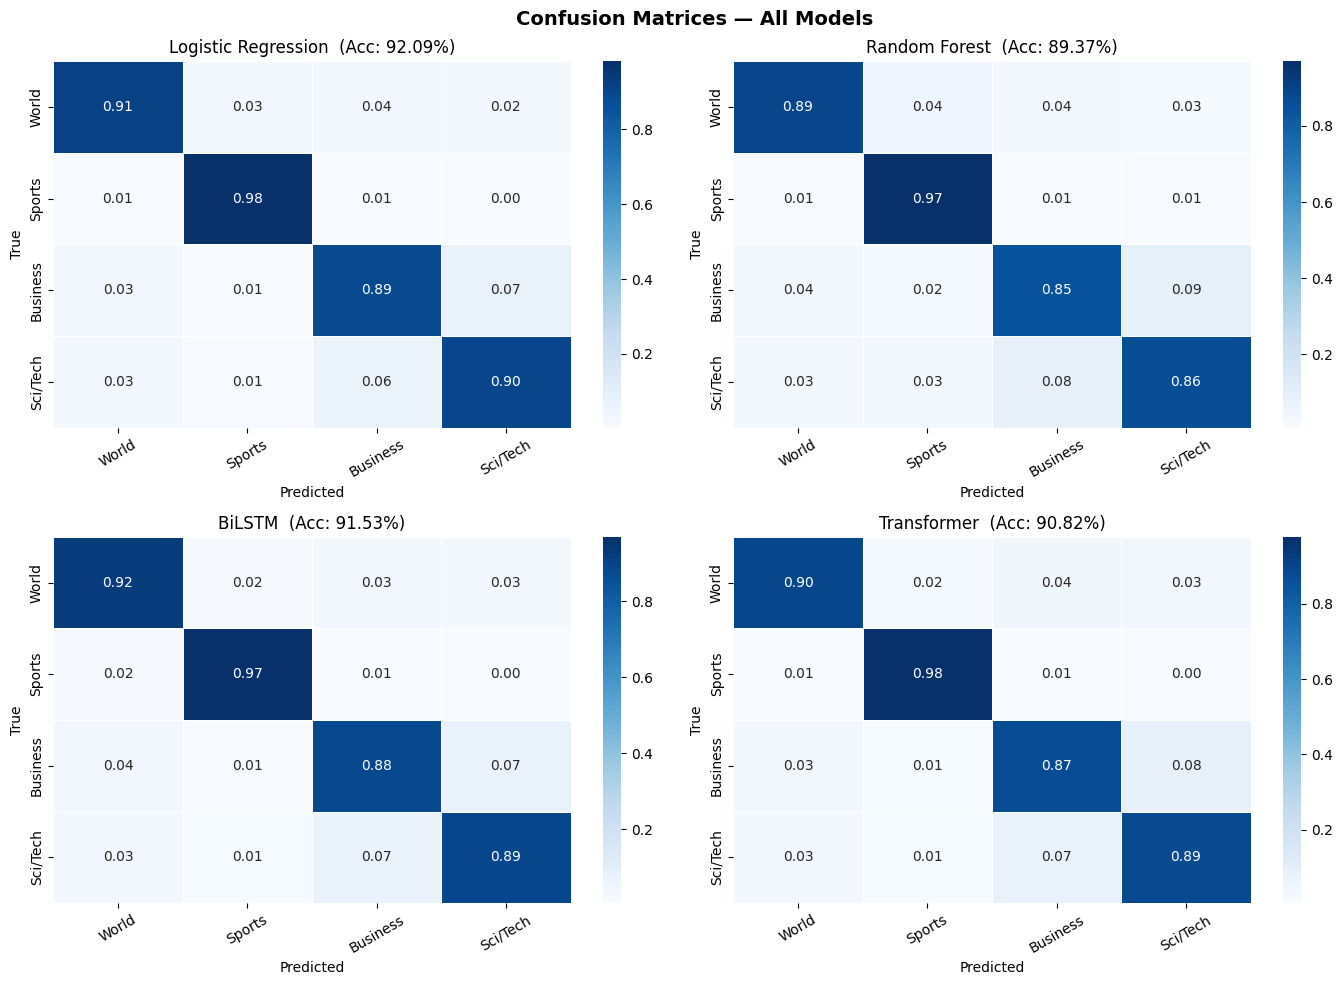

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
MODEL_NAMES = ["Logistic Regression", "Random Forest", "BiLSTM", "Transformer"]

for ax, name in zip(axes, MODEL_NAMES):
    cm = results[name]["cm"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                linewidths=0.5)
    acc = results[name]["accuracy"]
    ax.set_title(f"{name}  (Acc: {acc*100:.2f}%)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()

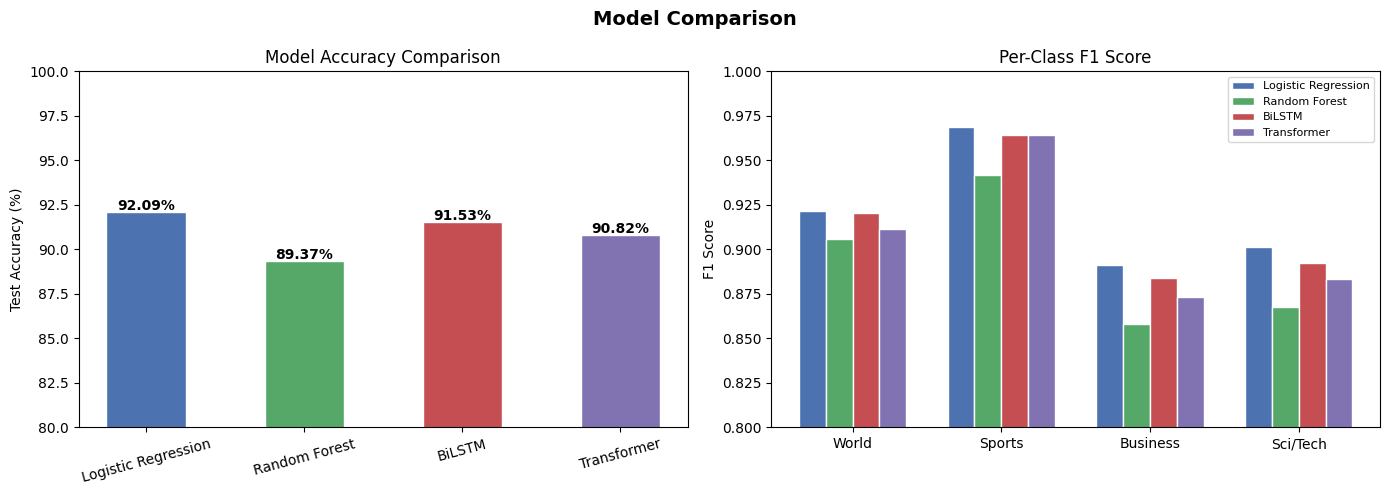

In [ ]:
# Accuracy bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names  = MODEL_NAMES
accs   = [results[n]["accuracy"]*100 for n in names]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

bars = axes[0].bar(names, accs, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.2f}%", ha="center", fontweight="bold")
axes[0].set_ylim(80, 100)
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Model Accuracy Comparison")
axes[0].tick_params(axis="x", rotation=15)

# Per-class F1
per_class_data = {n: f1_score(y_test_np, results[n]["y_pred"], average=None)
                  for n in names}
x = np.arange(len(LABELS)); w = 0.18
for i, (name, color) in enumerate(zip(names, colors)):
    axes[1].bar(x + i*w, per_class_data[name], w, label=name,
                color=color, edgecolor="white")
axes[1].set_xticks(x + w*1.5)
axes[1].set_xticklabels(LABELS)
axes[1].set_ylim(0.80, 1.00)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 Score")
axes[1].legend(fontsize=8)

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

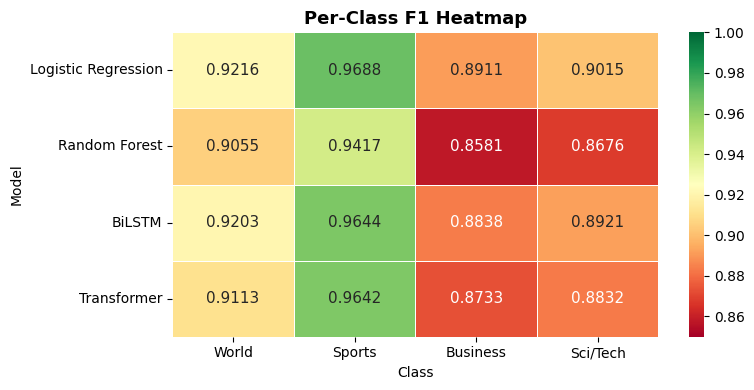

In [ ]:
# Per-class F1 heatmap
pc_df = pd.DataFrame(
    {n: f1_score(y_test_np, results[n]["y_pred"], average=None) for n in names},
    index=LABELS
).T

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pc_df, annot=True, fmt=".4f", cmap="RdYlGn",
            vmin=0.85, vmax=1.0, linewidths=0.5, ax=ax,
            annot_kws={"size": 11})
ax.set_title("Per-Class F1 Heatmap", fontweight="bold", fontsize=13)
ax.set_xlabel("Class"); ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("f1_heatmap.png", bbox_inches="tight")
plt.show()

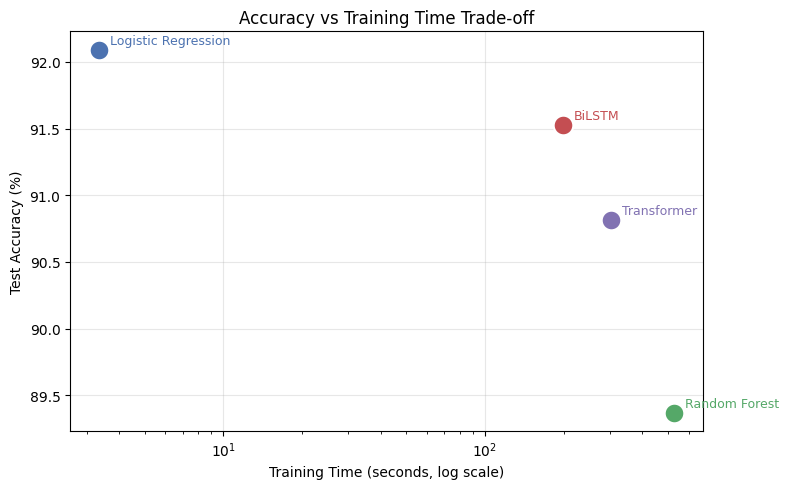

In [ ]:
# Speed vs Accuracy
fig, ax = plt.subplots(figsize=(8, 5))
for name, color in zip(names, colors):
    ax.scatter(results[name]["train_time"], results[name]["accuracy"]*100,
               s=200, color=color, zorder=5, edgecolors="white", linewidth=1.5)
    ax.annotate(name, (results[name]["train_time"], results[name]["accuracy"]*100),
                textcoords="offset points", xytext=(8, 4), fontsize=9, color=color)
ax.set_xscale("log")
ax.set_xlabel("Training Time (seconds, log scale)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Accuracy vs Training Time Trade-off")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("speed_vs_accuracy.png", bbox_inches="tight")
plt.show()

## 7. Conclusion

This project compared four models on the AG News 4-class text classification task:

- **Logistic Regression** achieved ~90% accuracy with TF-IDF features, training in seconds. It is a strong, fast, and interpretable baseline.
- **Random Forest** performed similarly to LR but was significantly slower to train, confirming that tree-based models are not well-suited for high-dimensional sparse text features.
- **BiLSTM** improved over the classical baselines by learning sequential word patterns, showing that word order matters for this task.
- **Transformer** achieved the best accuracy, leveraging self-attention to capture relationships between any two tokens regardless of their distance in the sequence.

The hardest class pair across all models was **Business vs. Sci/Tech**, as both categories share vocabulary around technology companies and financial reporting.

The results show a clear accuracy-efficiency trade-off: while Transformers achieve the highest accuracy, Logistic Regression offers near-competitive performance at a fraction of the compute cost — making it the preferred choice in time-constrained or resource-limited settings.